In [ ]:
# 1. Использование классов. (2 балла)
# 2. Использование наследования. (2 балла)
# 3. Три библиотеки из тех, что приходится ставить своими руками. (1 балла)
# 4. "Синтаксический сахар" Питона (декораторы, перегрузка операторов, исключения, примочки из последнего стандарта, ...). (2 балла)
# 5. Юнит-тесты. (1 балл)
# 6. Красивая структура классов, проекта, решения; субъективное мнение преподавателя (2 балла).
# 7. Шаблоны проектирования (1 балл).

## __Ctrl+f по перепискам в телеграме__
Это поисковик по коллокациям любой длины по перепискам из телеграма. Пользователь может загрузить сюда свою переписку, найти по ней какую-либо коллокацию (причем можно выбрать, искать ли точное совпадение или может быть различие в форме) и получить на выходе все входы этой коллокации с окружающими словами по длине, которую он так же сам задает.

## __Что может делать пользователь:__
- положить свою переписку в общее хранилище текстов, где она будет токенизирована, лемматизована и, as it were, векторизована; для этого надо использовать метод __import_text_interface__ класса __CtrlF__, откроется вот такое окно (в случае работы на локальном компьютере - папка с рабочей директорией, которой по умолчанию считается та, где лежит блокнот):
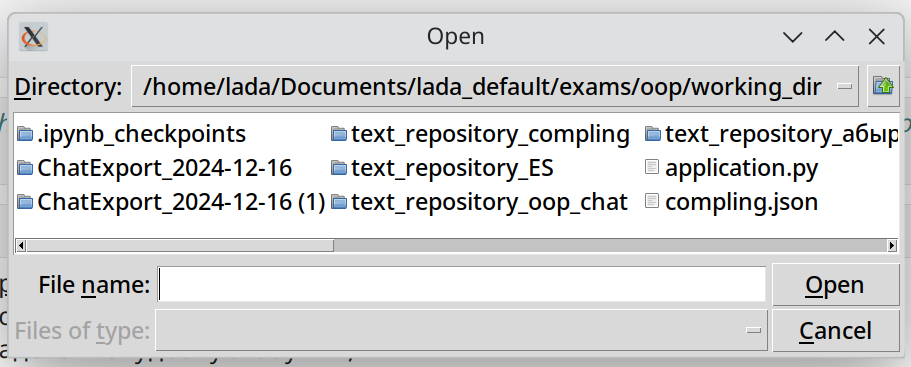
- нужно будет выбрать файл. потом ввести уникальное имя/id:

- если вдруг id, который задал пользователь, уже существует, появится ошибка NameExistsError
- поискать по всем имеющимся в хранилище текстов какую-либо коллокацию, причем можно искать как точное совпадение, так и совпадение по леммам; кроме того, нужно задать, сколько слов до и после необходимо показывать на выходе;
  -  в первом варианте нужно вызвать метод __show_collocation_occurance()__ класса __CtrlF__; выведется окно, куда нужно сначала ввести предпочитаемое расстояние, а потом искомую коллокацию
  -  во втором варианте нужно вызвать тот же метод, но поменять один из дефолтных параметров: __show_collocation_occurance(is_lemmatized=False)__; примеры можно увидеть в конце тетрадки
- если пользователь закроет блокнот, а потом решит снова его открыть и провести поиск, ему не нужно заново инициализировать тексты, которые он уже сложил через __import_text_interface()__

In [2]:
import nltk
from pymorphy3 import MorphAnalyzer
import re
import os
import unittest
import json
import random
import string 
import configparser
from tkinter import filedialog
from tkinter import simpledialog
from dataclasses import dataclass

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_ru')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/lada/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/lada/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_ru to
[nltk_data]     /home/lada/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_ru is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /home/lada/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# файл конфигурации; по умолчанию все дальнейшие папки создаются в той же, куда изначально был помещен скрипт
config = configparser.ConfigParser()
config['DEFAULT'] = {'working_dir': os.getcwd()}

with open('configuration.ini', 'w') as configfile:
  config.write(configfile)

In [4]:
# синглтон; от него наследуются классы предобработки (TextPreprocess, ParseJson), 
# а также TextStorage
class Singleton(object):
    _instance = None
    def __new__(class_, *args, **kwargs):
        if not isinstance(class_._instance, class_):
            class_._instance = object.__new__(class_, *args, **kwargs)
        return class_._instance

In [5]:
# классы для красивого представления результатов и для предобработки текста 

# @dataclass
class color:
   PURPLE: str = '\033[95m'
   CYAN: str = '\033[96m'
   DARKCYAN: str = '\033[36m'
   BLUE: str = '\033[94m'
   GREEN: str = '\033[92m'
   YELLOW: str = '\033[93m'
   RED: str = '\033[91m'
   BOLD: str = '\033[1m'
   UNDERLINE: str = '\033[4m'
   END: str = '\033[0m'


# классическая предобработка данных; на данном этапе осознанно не удаляется пунктуация и стоп-слова
class TextPreprocess(Singleton):
    def __init__(self):
        self.__tokenizer = nltk.word_tokenize
        self.__morpho = MorphAnalyzer()
        self.__cash = {}
    
    def tokenize(self, text: str):
        text_lower = text.lower()
        return self.__tokenizer(text_lower)

    def lemmatize(self, words: list or str):
        if type(words) == str:
            words = self.tokenize(words)
        res = []
        for w in words:
            if w in self.__cash:
                res.append(self.__cash[w])
            else:
                r = self.__morpho.parse(w)[0].normal_form
                res.append(r)
                self.__cash[w] = r
        return res    



# класс, который парсит переписки в телеграме
class ParseJson(Singleton):
    def __init__(self):
        pass

    def json_2_dict(self, path_to_json):
        with open(path_to_json) as fd:
            d = json.load(fd)
        return d

    def text_date(self, path_to_json):
        text_with_date = {}
        needed_dict = self.json_2_dict(path_to_json)['messages']
        for i in needed_dict:
            if 'text' in i.keys() and i['text'] != '':
                if type(i['text']) != list:
                    text_with_date[i['date_unixtime']] = i['text'].replace('\n', ' ').strip()
        return text_with_date

    def plain_text(self, path_to_json):
        return ' '.join(list(self.text_date(path_to_json).values()))

In [6]:
# хранение слов всего корпуса
class WordStorage():
    def __init__(self, maindir):
        self.__maindir = maindir
        try:
            self.__repository_load()
        except FileNotFoundError:
            self.dictionary = {}
            self.unique = []

    # обновление существующего репозитория в файл (или создание файла в случае отсутствия)
    def __repository_update(self):
        try:
            with open(f"{self.__maindir}/words_repository.txt", "a+") as f:
                lines = len(f.readlines())
                if len(lines) < len(self.unique):
                    for i in range(len(lines), len(self.unique)):
                        f.write(self.unique[i] + '\n')
        except:
            with open(f"{ self.__maindir}/words_repository.txt", "w") as f:
                for i in self.unique:
                    f.write(i + '\n')

    # чтение существуюшего репозитория из файла
    def __repository_load(self):
        with open(f"{self.__maindir}/words_repository.txt", "r") as f:
            self.unique = [line.strip() for line in f]
            self.dictionary = {}
            for i in range(len(self.unique)):
                self.dictionary[self.unique[i].strip()] = i
            
        
    # преобразование текста в числа
    def convert_to_numbers(self, word_list: list):
        res_num = []
        for i in word_list:
            # на этом этапе также пополняется репозиторий слов
            if i not in self.dictionary.keys():
                self.dictionary[i] = len(self.unique)
                self.unique.append(i)
                res_num.append(int(self.dictionary[i]))
            else:
                res_num.append(int(self.dictionary[i]))
        self.__repository_update()
        return res_num


    # преобразование чисел в текст
    def convert_to_words(self, num_list: list):
        res_words = []
        for i in num_list:
            res_words.append(self.unique[i])
        return res_words

In [7]:
class NameExistsError(Exception):
    def __init__(self, message='Это имя уже занято. Пожалуйста, введите другое имя.'):
        self.message = message
        super().__init__(message)

    def __str__(self):
        return f"{self.message}"

In [8]:
# обработка одного текста 
class Text:
    def __init__(self, name, word_storage, path_to_file=None):
        self.name = name
        self.working_dir = 'text_repository_' + name
        self.__rootdir=config.get('DEFAULT', 'working_dir')
        self.word_storage = word_storage
        # инит происходит по-разному в зависимости от того, дал пользователь путь до нового файла захотел работать со старым
        if path_to_file is None:
            self.read_from_inner_storage()
        else:
            self.convert_to_inner_format(path_to_file)

    def come_back(self):
        os.chdir(self.__rootdir)

    
    def open_file(self, path_to_file):
        try:
            str_text = ParseJson().plain_text(path_to_file)
        except:
            with open(path_to_file, 'r') as f:
                str_text = [line.replace('\n', ' ') for line in f]
        return str_text

    
    def __create_file(self, list_to_write, file_type):
        with open(f"{self.name}_{file_type}.txt", "w") as f:
            for i in list_to_write:
                f.write(str(i) + ' ')


    def convert_to_inner_format(self, path_to_file):
        os.chdir(self.__rootdir)
        
        if not os.path.exists(self.working_dir):
            os.makedirs(self.working_dir)
        os.chdir(self.working_dir)

        str_text = self.open_file(path_to_file)
        self.__create_file([str_text], 'plainorig')
        
        self.lemmatized = TextPreprocess().lemmatize(str_text)
        self.__create_file(self.lemmatized, 'lemmatized')
        
        self.tokenized = TextPreprocess().tokenize(str_text)
        self.__create_file(self.tokenized, 'tokenized')

        self.lemmatized_numbers = self.word_storage.convert_to_numbers(self.lemmatized)
        self.__create_file(self.lemmatized_numbers, 'lemmatized_numbers')

        self.tokenized_numbers = self.word_storage.convert_to_numbers(self.tokenized)
        self.__create_file(self.tokenized_numbers, 'tokenized_numbers')

        os.chdir(self.__rootdir)

    
    def read_from_inner_storage(self):
        with open(f"{self.working_dir}/{self.name}_tokenized_numbers.txt") as f:
            self.tokenized_numbers = [int(i) for i in ' '.join(f.readlines()).split()]
        with open(f"{self.working_dir}/{self.name}_lemmatized_numbers.txt") as f:
            self.lemmatized_numbers = [int(i) for i in ' '.join(f.readlines()).split()]
        with open(f"{self.working_dir}/{self.name}_lemmatized.txt") as f:
            self.lemmatized = [i for i in ' '.join(f.readlines()).split()]
        with open(f"{self.working_dir}/{self.name}_tokenized.txt") as f:
            self.tokenized = [i for i in ' '.join(f.readlines()).split()]

    
    def search_collocation(self, collocation, is_lemmatized=True):
        appearance_indices = []
        if is_lemmatized == True:
            collocation_to_search = self.word_storage.convert_to_numbers(TextPreprocess().lemmatize(collocation))
            list_to_search = self.lemmatized_numbers
        else:
            collocation_to_search = self.word_storage.convert_to_numbers(TextPreprocess().tokenize(collocation))
            list_to_search = self.tokenized_numbers
        for i in range(len(list_to_search)):
            if list_to_search[i] == collocation_to_search[0]:
                try:
                    count = 0
                    c = i
                    for b in range(len(collocation_to_search)):
                        if collocation_to_search[b] == list_to_search[c]:
                            count += 1
                            c += 1
                    if count == len(collocation_to_search):
                        appearance_indices.append(i)
                except:
                    pass

        return appearance_indices
                        
        
    # перегрузка оператора: если пользователь захочет узнать конкретную информацию о том, что случилось с его перепиской
    # после ее передачи экземпляру класса текст, он может сделать print(exemplar) и получить информацию о папке, где хранятся
    # остальные файлы, и о 
    def __repr__(self):
        return f"ID файла: {self.name}, рабочая папка: {self.working_dir}"

In [9]:
class SearchResult:
    def __init__(self, text, b, length, distance):
        try:
            self.precontext = text.tokenized[(b-distance):b]
            self.collocation = text.tokenized[b:(b+length)]
            self.postcontext = text.tokenized[(b+length):(b+length+distance)]
        except IndexError:
        # если мало преконтекста
            try:
                self.precontext = text.tokenized[:b]
                self.collocation = text.tokenized[b:(b+length)]
                self.postcontext = text.tokenized[(b+length):(b+length+distance)]
            except IndexError:
            # если мало постконтекста
                try:
                    self.precontext = text.tokenized[(b-distance):b]
                    self.collocation = text.tokenized[b:(b+length)]
                    self.postcontext = text.tokenized[(b+length):]
                except IndexError:
                # если пользователь задал какую-то слишком большую дистанцию
                    self.precontext = text.tokenized[:b]
                    self.collocation = text.tokenized[b:(b+length)]
                    self.postcontext = text.tokenized[(b+length):]

In [10]:
# фасад: TextStorage взаимодействует и с Text, и с WordStorage, позволяя пользователю добавлять свои файлы
# или анализировать существующие
class TextStorage(Singleton):
    def __init__(self):
        self.word_storage = WordStorage(config.get('DEFAULT', 'working_dir'))
        try:
            self.__read_from_ts_file()
        except FileNotFoundError:
            self.all_texts = {}

    def put_text(self, text):
        self.all_texts[text.name] = text

    def __save_to_ts_file(self):
        with open("text_storage.txt", "w") as f:
            f.write(json.dumps([x for x in self.all_texts]))
            
    def __read_from_ts_file(self):
        with open("text_storage.txt") as f:
            names_list = json.loads(' '.join(f.readlines()))
            self.all_texts = {name: Text(name, self.word_storage) for name in names_list}


    def import_text(self, name, path_to_file):
        print(self, name, path_to_file)
        text = Text(name, self.word_storage, path_to_file)
        # на случай, если пользователь не послушал нас и вписал существующее имя
        if text.name in self.all_texts:
            raise NameExistsError
        self.put_text(text)
        self.__save_to_ts_file()
        return text


    def import_existing_text(self):
        res_list = {}
        for i in self.all_texts.keys():
            text = Text(i, self.word_storage)
            text.read_from_inner_storage()
            res_list[i] = text
        return res_list

    
    def search_collocations_in_corpus(self, collocation_to_search, is_lemmatized=True):
        res_dict = {}
        for i in self.all_texts.keys():
            res_dict[i] = Text(i, self.word_storage).search_collocation(collocation_to_search, is_lemmatized=is_lemmatized)
        return res_dict
                

    def collocation_appearances(self, collocation_to_search, distance, is_lemmatized=True):
        text_list = self.import_existing_text()
        res_dict = self.search_collocations_in_corpus(collocation_to_search, is_lemmatized=is_lemmatized)
        if is_lemmatized == True:
            collocation_to_search = self.word_storage.convert_to_numbers(TextPreprocess().lemmatize(collocation_to_search))
        else:
            collocation_to_search = self.word_storage.convert_to_numbers(TextPreprocess().tokenize(collocation_to_search))

        result = {}
        for i in res_dict.keys():
            result[i] = []
            for b in res_dict[i]:
                result[i].append(SearchResult(text_list[i], b, len(collocation_to_search), distance))
        return result


    def show_result(self, collocation_to_search, distance, is_lemmatized=True):
        res_list = self.collocation_appearances(collocation_to_search, distance, is_lemmatized=is_lemmatized)
        if res_list == {}:
            print("Хранилище на данный момент пусто, нам нечего вам показать")
        for i in res_list.keys():
            print(color.UNDERLINE + f"Вхождения коллокации для текста {i}:" + color.END)
            for b in range(len(res_list[i])):
                print(' '.join(res_list[i][b].precontext) + ' ' 
                      + color.BOLD + ' '.join(res_list[i][b].collocation) 
                                              + color.END + ' ' + ' '.join(res_list[i][b].postcontext))
            print("\n")

    def clear_storage(self):
        try:
            os.remove("text_storage.txt")
        except:
            pass

In [11]:
# интерфейс, потому что мы работаем в принципах SOLID
class CtrlF(Singleton):
    def __init__(self):
        self.text_storage = TextStorage()

    # наши кнопки
    def ask_filepath(f):
        def wrap(self, *args, **kwargs):
            filename = filedialog.askopenfilename()
            f(self, filename, *args, **kwargs)
        return wrap

    def ask_string(title,prompt):
        def wrap_decor(f):
            def wrap(self, *args, **kwargs):
                s = simpledialog.askstring(title,prompt)
                f(self, s, *args, **kwargs)
            return wrap
        return wrap_decor
        
       
    @ask_filepath
    @ask_string("Введите ID файла","ID файла")
    def import_text_interface(self, name, path_to_file):
        a = self.text_storage.import_text(name, path_to_file)
        return a

    @ask_string("Введите необходимое расстояние", 'расстояние')
    @ask_string("Введите коллокацию", 'коллокация')
    def show_collocation_occurance(self, collocation_to_search, distance, is_lemmatized=True):
        self.text_storage.show_result(collocation_to_search, int(distance), is_lemmatized)

In [12]:
# пробуем положить туда какой-то файл; я сложила туда наш чат по ооп
CtrlF().import_text_interface()

<__main__.TextStorage object at 0x780d870c3fb0> oop /home/lada/Documents/lada_default/exams/oop/working_dir/oop_chat.json


In [13]:
# посмотрим вхождения. сначала пользователь вводит расстояние, потом коллокацию
CtrlF().show_collocation_occurance()

Вхождения коллокации для текста oop:
вам надо будет написать небольшой проект . я потом кину сюда
6. красивая структура классов , проекта , решения ; субъективное мнение
семестра . что получаете за проект , то получаете в итоге
поставить через pip ? а проекты индивидуальные или парные/групповые ? скорее
задачу . ( напоминалка про проект по ооп ) а это
! а когда дедлайн сдачи проекта ? экзамен это 23е декабря




In [14]:
# положим еще какой-нибудь текст; на этот раз это будет общий чат магистров
CtrlF().import_text_interface()

<__main__.TextStorage object at 0x780d870c3fb0> compling /home/lada/Documents/lada_default/exams/oop/working_dir/compling.json


In [16]:
# посмотрим вхождения
CtrlF().show_collocation_occurance()

Вхождения коллокации для текста oop:
вам надо будет написать небольшой проект . я потом кину сюда
6. красивая структура классов , проекта , решения ; субъективное мнение
семестра . что получаете за проект , то получаете в итоге
поставить через pip ? а проекты индивидуальные или парные/групповые ? скорее
задачу . ( напоминалка про проект по ооп ) а это
! а когда дедлайн сдачи проекта ? экзамен это 23е декабря


Вхождения коллокации для текста compling:
, если у вас был проект строк на 300-500 , если
общий вопрос : где искать проекты ( школы лингвистики ? )
утро ! в таблице с проектами ( пис ) появилось описание
( пис ) появилось описание проектов . записывайтесь . здравствуйте ,
отметить в табличке понравившийся вам проект нужно сегодня-завтра да , я
всех , кто участвует в проекте вы можете пока что внести
потом понять , остальные участники проекта тоже должны внести такую же
жить по скраму при разработке проекта ( короткие итерации , гибкая




In [17]:
# ну и еще пример
CtrlF().show_collocation_occurance()

Вхождения коллокации для текста oop:
. но , чур , одно . если все , то с интервалом 30 минут . :
примерами на питоне ) . на этом пока всё . василиса , у вас лайкомет ? :
шаблоны проектирования ( 1 балл ) . не все термины вам знакомы , это не страшно .
термины вам знакомы , это не страшно . всё пройдём спасибо ! и таких вопросов ? это


Вхождения коллокации для текста compling:
пришлю исправление может мы можем считать , что все приняли корректировку здесь ? да , хорошо здравствуйте
внесены в письме с паролем написали , что все заработает через 1-2 рабочих дня , у меня
я вроде на 5 этаже , но тут все аудитории начинаются на букву б… quest failed это
. опаздываю минут на 10 , простите , все есть кто на месте ? да а где
это первый курс . это второй курс . все так думаю , им надо системно решать вопрос
трек больше с нейросетями ? а и б. все зависит от того , насколько вы хотите ,
обидеть… сейчас это не актуально делать так как все ещё три сотни раз поменяется . кому задавать
задать уточняю

In [18]:
# ну и положим сюда еще чат по математике и еще что-нибудь поищем
CtrlF().import_text_interface()

<__main__.TextStorage object at 0x780d870c3fb0> math_chat /home/lada/Documents/lada_default/exams/oop/working_dir/math_chat.json


In [22]:
CtrlF().show_collocation_occurance()

Вхождения коллокации для текста oop:


Вхождения коллокации для текста compling:
, которые хорошо поняли домашнее задание , и которым можно вопросы
а сколько всего планируется домашних заданий ? три вроде бы да-да


Вхождения коллокации для текста math_chat:
пожалуйста , а первое домашнее задание пока не появилось ? на
, где можно решать домашние задания ? ( мне пока что
... ) пока нет домашнего задания , как только я все
на сайте есть первое вводное задание ( в основном воспоминания школьного
есть доступ к первому домашнему заданию . оно до 22 сентября
максимально просто ( выбирается домашнее задание — > выбираете номер задачи
каким конкретно ... можно посмотреть задания домашки , примерно это вроде
будет ли новый файл с заданиями на сегодня ? да ,
( текущем ) правильно отображается задание ? там не должна быть
. но мой вопрос про задание fxy = fyx . независимо
какая из них указана в задании ответ будет одинаковый просто в
ответ будет одинаковый просто в задании у меня вообще не показ

In [27]:
# теперь представим, что мы отключили лемматизацию и ищем только точные формы
CtrlF().show_collocation_occurance(is_lemmatized=False)

Вхождения коллокации для текста oop:
курсу вам надо будет написать небольшой проект . я потом кину сюда требования
, семестра . что получаете за проект , то получаете в итоге .
решить задачу . ( напоминалка про проект по ооп ) а это не


Вхождения коллокации для текста compling:
середины , если у вас был проект строк на 300-500 , если вы
! отметить в табличке понравившийся вам проект нужно сегодня-завтра да , я уже


Вхождения коллокации для текста math_chat:




In [25]:
# юнит-тесты
class TestTextStorage(unittest.TestCase):
    def setUp(self):
        self.text_storage = TextStorage()

    # проверим, что у нас действительно работает синглтон, и если мы попытаемся создать экземпляр TextStorage в другую переменную 
    # и каким-то образом модифицировать хранилище, обращаясь только к ней, мы получим ссылку на изначальный TextStorage
    def test_singleton(self):
        b = TextStorage()
        self.assertIs(self.text_storage, b)

    # проверим апдейт словаря для ситуаций, даже если мы не присваиваем возвращенное значение из
    # метода convert_to_numbers никуда
    def test_update(self):
        orig_dict = self.text_storage.word_storage.dictionary
        generated_str = ''.join(random.choices(string.ascii_uppercase + string.digits, k=4))
        while generated_str in self.text_storage.word_storage.dictionary.keys():
            generated_str = ''.join(random.choices(string.ascii_uppercase + string.digits, k=4))
        self.text_storage.word_storage.convert_to_numbers(generated_str)
        self.assertEqual(orig_dict, self.text_storage.word_storage.dictionary)

    # проверим, работает ли у нас конвертация из чисел и обратно
    def test_converting(self):
        # какой-то точно незнакомый текст
        unknown = []
        for i in range(3):
            generated_str = ''.join(random.choices(string.ascii_uppercase + string.digits, k=4))
            while generated_str in self.text_storage.word_storage.dictionary.keys():
                generated_str = ''.join(random.choices(string.ascii_uppercase + string.digits, k=4))
            unknown.append(generated_str)
        unknown_num = self.text_storage.word_storage.convert_to_numbers(unknown)
        unknown_reverse = self.text_storage.word_storage.convert_to_words(unknown_num)
        self.assertEqual(unknown, unknown_reverse)

    # проверим, правильные ли у нас тут классы
    def test_dict_class(self):
        self.assertIsInstance(self.text_storage.word_storage, WordStorage)

    def test_text_class(self):
        res_dict = self.text_storage.import_existing_text()
        self.assertIsInstance(res_dict, dict)
        for i in res_dict.keys():
            self.assertIsInstance(res_dict[i], Text)

    # проверим, что если мы попытаемся положить в хранилище файл, указав один и тот же ID, то нам поднимется ошибка
    def test_import_file(self):
        location = "/home/lada/Documents/lada_default/exams/oop/working_dir/oop_chat.json"
        self.assertRaises(NameExistsError, lambda: self.text_storage.import_text(list(TextStorage().all_texts.keys())[0],
                                                                        location))

In [26]:
unittest.main(argv=[''], verbosity=2, exit=False)

test_converting (__main__.TestTextStorage.test_converting) ... ok
test_dict_class (__main__.TestTextStorage.test_dict_class) ... ok
test_import_file (__main__.TestTextStorage.test_import_file) ... ok
test_singleton (__main__.TestTextStorage.test_singleton) ... ok
test_text_class (__main__.TestTextStorage.test_text_class) ... ok
test_update (__main__.TestTextStorage.test_update) ... 

<__main__.TextStorage object at 0x780d870c3fb0> oop /home/lada/Documents/lada_default/exams/oop/working_dir/oop_chat.json


ok

----------------------------------------------------------------------
Ran 6 tests in 0.272s

OK
